#### Midterm 
Design the front end of a supersonic train. In engineering terms it is often the case that you want to maximize or minimize some performance metric while staying within some set of constraints

<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/Midterm%20-%20supersonic%20train%20Optimization/Train%20Side%20profile.png?raw=true" width="50%">



#### Strategy 

The total cost(point of optimization) is given by 

$C = 20 \times N \times D$
where 

1. C is optimization point COST
2. N is the number of trips N
3. D is the Drag in newtons 


$N = 2\left\lceil \frac{1}{V} \right\rceil - 1, \qquad 0 < V \le 1$



### Approach Strategy 

1. I will define the dotted line box to have 1 by 1 dimensions. 
<br>

2. I will make a function that takes in the number of vertice and linmaps out the possible vertice coordinates in the region

<br>

4. For the inviscid assumption, I will make a function that calculates the drag given the vertice locations 
5. For the viscocious assumption, [Ask in office hours on this approach]
<br>

6. I will use the two functions for multidomain optimization wtih scipy or pytorch(Look into documentation)
7. I will optimize and find the best possible solutions. 
<br>



Assumptions 

1. Conditions : <br>
    M = 3 <br>
    T = 300K <br>
    P = 101325 <br>
    L = 1m  
2. Analysis using the oblique shocks and expansion waves only 
3. Only care about the overall drag in the X direction
4. . This is my assumption. There's no way $\Sigma$ shaped train is better than 'bullet' shaped train. I'll work on its implementation but this is a rule that can minimax filter a lot of cases
5. In the given plane closed by the dotted line, the bottom left is (0,0). The top right is (1,1)

#### Thinking notes 
1. The trip number is probably explicitly discrete so that I can filter the search based on it

1. To go from 3 to 5 trips, I need at minium 66% decrease in drag to justify the trip cost. 

#### Cost optimization section

In [158]:
#The function Calculates the N, the required trip number, according to the polygon geometry
#The trip number is always odd : If you moved cargo the way from NYC to SF, just stay there 
#The trip number always rounds up. You need to move ALL the cargo
def Tripnumber(polygon): 
    trip = math.ceil(round(1 / polygon.area, 9))
    return 2 * trip - 1

#### Polygon section

In [199]:
import numpy as np
import matplotlib.pyplot as plt
import shapely.geometry as geo
import shapely.plotting as shplt
import math
import shapely
import random

A, B = (1, 1), (1, 0) 
n = 100  # axis grid count, n*n polygons

# https://shapely.readthedocs.io/en/latest/reference/shapely.make_valid.html
# I will use shapely make valid function to make valid train head profiles from given coordinates
pts = [(x, y) for y in np.linspace(0, 1, n) for x in np.linspace(0, 1, n)]
pts2 = [(x, y) for y in np.linspace(0.75, 1, n) for x in np.linspace(0, 1, n)]

def PolygonCreation(coordinates):
    return shapely.make_valid(geo.Polygon(coordinates))

#Triangles 
Triangles = [PolygonCreation([A, B, p]) for p in pts]

#Quadrilaterals 
Quads = [PolygonCreation([A, B, p, p2]) for p, p2 in zip(pts, pts2)]

In [218]:
# Plotting function to plot the given triangle using the shapely.plotting library
def plot_polygon(type,k):

    fig, ax = plt.subplots()
    shplt.plot_polygon(type[k], ax=ax, add_points=True)

    ax.annotate("A", A, textcoords="offset points",  fontsize=10)
    ax.annotate("B", B, textcoords="offset points",fontsize=10)
    ax.annotate(f"P1 ({pts[k][0]:.3f}, {pts[k][1]:.3f})", pts[k], textcoords="offset points", fontsize=10)


    if type != "Traingles":
        ax.annotate(f"P2 ({pts2[k][0]:.3f}, {pts2[k][1]:.3f})", pts2[k], textcoords="offset points", fontsize=10)


    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

    ax.set_title("Polygon check")

    plt.text(0,-0.1, f"Polygon {k}, Cargo volume = {round(type[k].area, 3)}")
    plt.text(0,-0.15, f"Polygon {k}, Trip required = {Tripnumber(type[k])}")
    plt.show()



C:\Users\tanka\AppData\Local\Temp\ipykernel_8464\1415334334.py:7: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate("A", A, textcoords="offset points",  fontsize=10)
C:\Users\tanka\AppData\Local\Temp\ipykernel_8464\1415334334.py:8: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate("B", B, textcoords="offset points",fontsize=10)
C:\Users\tanka\AppData\Local\Temp\ipykernel_8464\1415334334.py:9: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate(f"P1 ({pts[k][0]:.3f}, {pts[k][1]:.3f})", pts[k], textcoords="offset points", fontsize=10)
C:\Users\tanka\AppData\Local\Temp\ipykernel_8464\1415334334.py:13: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate(f"P2 ({pts2[k][0]:.3f}

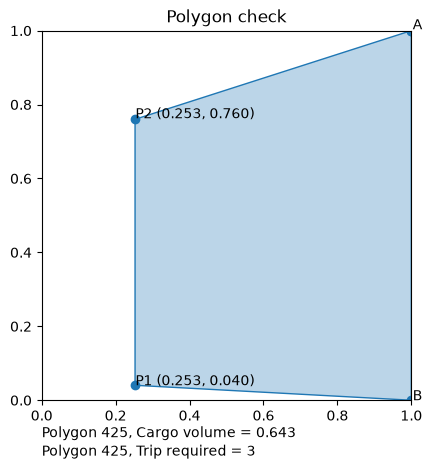

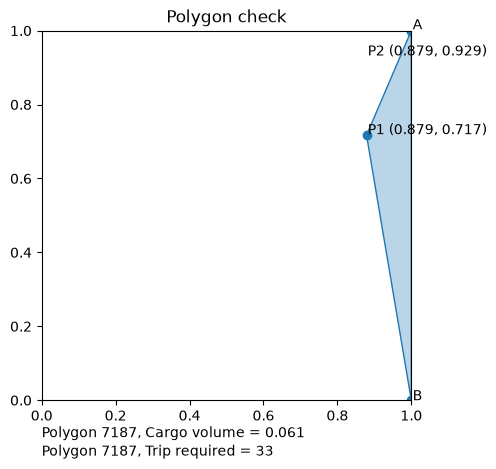

In [219]:
#In this polygon system I set up, since I just linspaced for x and then linspace for y, 
#The first two digits is y axis bottom-up and the last two digits is x axis right to left
plot_polygon(Quads, random.randint(0,10000))
plot_polygon(Triangles,random.randint(0,10000) )

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 44

TypeError: One of the arguments is of incorrect type. Please provide only Geometry objects.

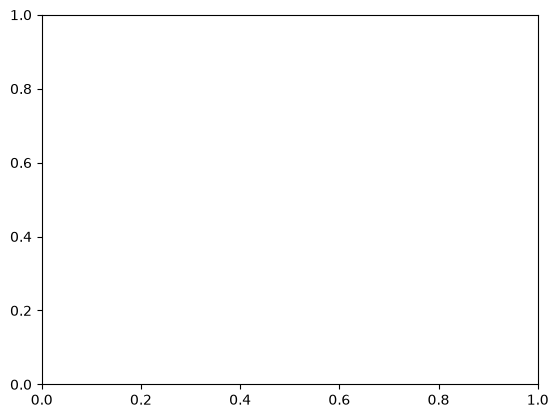

In [194]:
candidates = []

for k, poly in enumerate(polygons):
    if poly.area > 0 and Tripnumber(poly) <=3 :
        candidates.append(k)

print(candidates)

# You either do 3 trips or 5 trips for triangle 
# Makes sense with the problem premise : You need to come back, get the rest of the cargo, and go back. 
plot_polygon(125)

AttributeError: 'LineString' object has no attribute 'exterior'

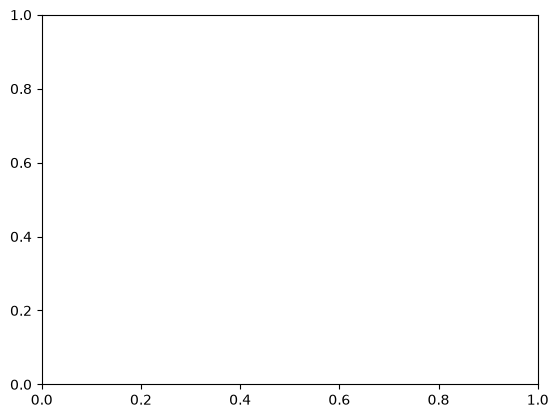